<a href="https://colab.research.google.com/github/KunalGosavi1/KunalGosavi1/blob/main/Maleria_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name :Kunal Krishna Gosavi

PRN :2324000163

Roll No.: A_15

Problem Statement:Maleria Detection Using VGG16


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
parasite_path = "/content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset/Train/Parasite"
uninfected_path = "/content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset/Train/Uninfected"

print(f"Parasite path: {parasite_path}")
print(f"Uninfected path: {uninfected_path}")

Parasite path: /content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset/Train/Parasite
Uninfected path: /content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset/Train/Uninfected


In [ ]:
#import Libreries
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

In [ ]:
dataset_path = "/content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset"

train_path = dataset_path + "/Train"

test_path = dataset_path + "/Test"

In [ ]:
#img data generator
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True

)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
#train load dataset
dataset_path = "/content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset"
train_path = dataset_path + "/Train"

print(f"Corrected train path: {train_path}")

train_data = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='binary'

)

Corrected train path: /content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset/Train
Found 436 images belonging to 2 classes.


In [ ]:
#Load test dataset
test_data = test_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='binary'

)

Found 134 images belonging to 2 classes.


In [ ]:
# load model--VGG16
vgg = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#freez pretrain model
for layer in vgg.layers:
    layer.trainable = False

In [ ]:
model = Sequential()

# Add VGG16 Base
model.add(vgg)

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(256, activation='relu'))

# Batch Normalization
model.add(BatchNormalization())

# Dropout Layer
model.add(Dropout(0.5))

# Another Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [ ]:
# compile_model
model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,171,521 (80.76 MB)

 Trainable params: 6,456,321 (24.63 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [ ]:
# train the model
history = model.fit(

    train_data,

    validation_data=test_data,

    epochs=10

)


Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 113s 7s/step - accuracy: 0.6422 - loss: 0.6474 - val_accuracy: 0.7164 - val_loss: 0.5873
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 659ms/step - accuracy: 0.7661 - loss: 0.4818 - val_accuracy: 0.7313 - val_loss: 0.5786
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 612ms/step - accuracy: 0.8257 - loss: 0.3633 - val_accuracy: 0.7463 - val_loss: 0.5768
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 705ms/step - accuracy: 0.8188 - loss: 0.3852 - val_accuracy: 0.7836 - val_loss: 0.5323
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 710ms/step - accuracy: 0.8486 - loss: 0.3312 - val_accuracy: 0.7612 - val_loss: 0.5428
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 560ms/step - accuracy: 0.8807 - loss: 0.2768 - val_accuracy: 0.8433 - val_loss: 0.4517
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 662ms/step - accuracy: 0.8945 - loss: 0.2641 - val_accuracy: 0.8731 - val_loss: 0.4026
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 596ms/step - accuracy: 0.9083 - loss: 0.2529 - val_accuracy: 0

In [ ]:
# model Evalution
loss, accuracy = model.evaluate(test_data)

print("\nTest Accuracy :", accuracy * 100)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.8358 - loss: 0.3180

Test Accuracy : 83.58209133148193


In [ ]:
# save model
model.save("/content/drive/MyDrive/maleria detection/malaria_vgg16_model.h5")

print("\nModel Saved Successfully!")


Model Saved Successfully!


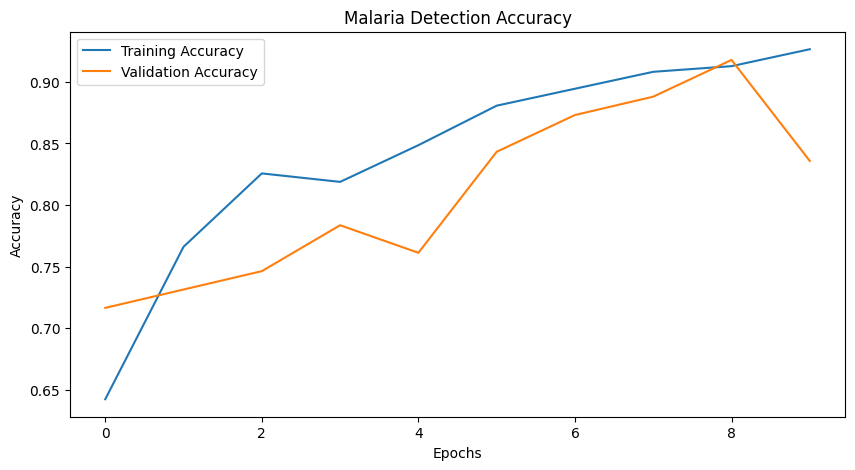

In [ ]:
# Accuracy of model
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Malaria Detection Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_image(image_path):

    # Read image
    img = cv2.imread(image_path)

    # Check image loaded or not
    if img is None:
        print("Image not found!")
        return

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image
    resized_img = cv2.resize(img_rgb, (224,224))

    # Normalize image
    resized_img = resized_img / 255.0

    # Reshape image for model
    reshaped_img = np.reshape(resized_img, (1,224,224,3))

    # Predict
    prediction = model.predict(reshaped_img)

    # Prediction value
    prediction_value = prediction[0][0]

    print("\nPrediction Value :", prediction_value)

    # Display image
    plt.imshow(img_rgb)
    plt.axis('off')

    # Classification
    if prediction_value > 0.5:

        plt.title("Result : Uninfected")

        print("\nResult : Uninfected")

    else:

        plt.title("Result : Parasitized")

        print("\nResult : Parasitized")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Prediction Value : 0.061528213

Result : Parasitized


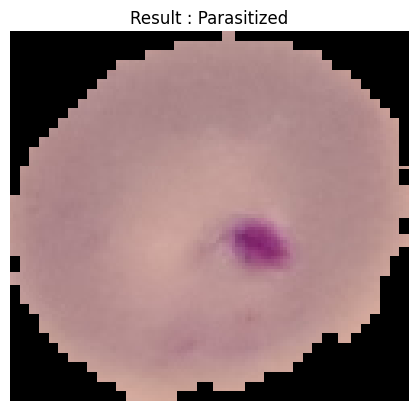

In [ ]:
test_image = "/content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset/Test/Parasite/C39P4thinF_original_IMG_20150622_105554_cell_10.png"

predict_image(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Prediction Value : 0.3371908

Result : Parasitized


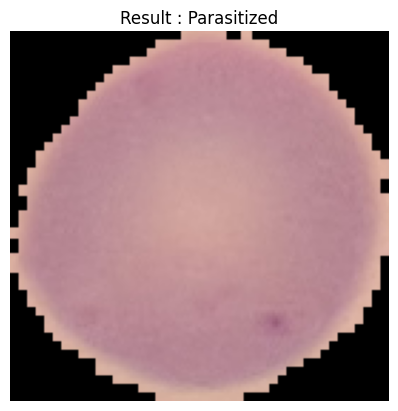

In [ ]:
test_image = "/content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset/Test/Uninfected/C3thin_original_IMG_20150608_163002_cell_159.png"

predict_image(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Prediction Value : 0.061528213

Result : Parasitized


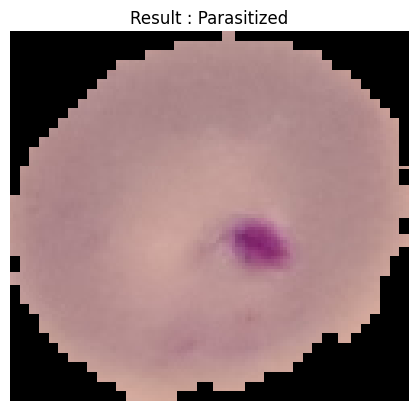

In [ ]:
test_image = "/content/drive/MyDrive/DL_Lab/Maleria_detection/Maleria_Dataset/Test/Parasite/C39P4thinF_original_IMG_20150622_105554_cell_10.png"

predict_image(test_image)